In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Load cleaned data
tb_data = pd.read_csv('kncv_nigeria_tb_data_cleaned.csv')

date_cols = ['screening_date', 'diagnosis_date', 'treatment_start_date', 'outcome_date']
for col in date_cols:
    tb_data[col] = pd.to_datetime(tb_data[col], errors='coerce')

print("Shape:", tb_data.shape)

Shape: (60000, 27)


In [2]:
# ── STEP 1: PREPARE DATA ─────────────────────────────────────────

# We only want confirmed TB patients with known outcomes
model_data = tb_data[
    tb_data['tb_type'].notna() & 
    tb_data['treatment_outcome'].notna()
].copy()

print("Confirmed TB patients with outcomes:", model_data.shape[0])

# Create binary target variable
# 1 = Treatment Success, 0 = Unsuccessful (Died, LTFU, Failed, Not Evaluated)
model_data['outcome_binary'] = (
    model_data['treatment_outcome'] == 'Treatment Success'
).astype(int)

print("\nOutcome distribution:")
print(model_data['outcome_binary'].value_counts())
print(f"\nSuccess rate: {model_data['outcome_binary'].mean()*100:.1f}%")

Confirmed TB patients with outcomes: 35884

Outcome distribution:
outcome_binary
1    24162
0    11722
Name: count, dtype: int64

Success rate: 67.3%


In [3]:
# ── STEP 2: SELECT FEATURES ──────────────────────────────────────

# Features we'll use to predict outcome
features = [
    'tb_type',
    'is_plhiv',
    'is_child_under15',
    'is_high_risk_setting',
    'dots_method',
    'treatment_facility_level',
    'treatment_regimen',
    'state'
]

# Select features and target
X = model_data[features].copy()
y = model_data['outcome_binary'].copy()

print("Features shape:", X.shape)
print("\nSample:")
print(X.head())

Features shape: (35884, 8)

Sample:
  tb_type is_plhiv is_child_under15 is_high_risk_setting  \
0   DR-TB       No               No                   No   
2   DS-TB       No               No                   No   
3   DS-TB       No               No                  Yes   
6   DS-TB       No               No                   No   
8   DS-TB       No               No                   No   

              dots_method treatment_facility_level      treatment_regimen  \
0           Facility DOTS                  Primary  Shorter DR-TB Regimen   
2           Facility DOTS                  Primary              2HRZE/4HR   
3           Facility DOTS                Secondary              2HRZE/4HR   
6                  99DOTS                Secondary              2HRZE/4HR   
8  Video Observed Therapy                Secondary              2HRZE/4HR   

     state  
0  Katsina  
2     Osun  
3      Imo  
6   Rivers  
8    Lagos  


In [4]:
# ── STEP 3: ENCODE CATEGORICAL VARIABLES ─────────────────────────

# Label encode all features
# (converts text categories to numbers)
le = LabelEncoder()

X_encoded = X.copy()
for col in X_encoded.columns:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print("Encoded features:")
print(X_encoded.head())
print("\nData types after encoding:")
print(X_encoded.dtypes)

Encoded features:
   tb_type  is_plhiv  is_child_under15  is_high_risk_setting  dots_method  \
0        0         0                 0                     0            2   
2        1         0                 0                     0            2   
3        1         0                 0                     1            2   
6        1         0                 0                     0            0   
8        1         0                 0                     0            3   

   treatment_facility_level  treatment_regimen  state  
0                         0                  4     10  
2                         0                  0     15  
3                         1                  0      7  
6                         1                  0     18  
8                         1                  0     12  

Data types after encoding:
tb_type                     int64
is_plhiv                    int64
is_child_under15            int64
is_high_risk_setting        int64
dots_method        

In [5]:
# ── STEP 4: TRAIN/TEST SPLIT ─────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # so we get same results every time
    stratify=y          # keep same success/failure ratio in both sets
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set: {X_test.shape[0]} patients")
print(f"\nTraining success rate: {y_train.mean()*100:.1f}%")
print(f"Testing success rate: {y_test.mean()*100:.1f}%")

Training set: 28707 patients
Testing set: 7177 patients

Training success rate: 67.3%
Testing success rate: 67.3%


In [6]:
# ── STEP 5: TRAIN THE MODEL ───────────────────────────────────────

# Initialize and train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print(" Model trained successfully!")
print(f"\nFeatures used: {list(X_encoded.columns)}")

 Model trained successfully!

Features used: ['tb_type', 'is_plhiv', 'is_child_under15', 'is_high_risk_setting', 'dots_method', 'treatment_facility_level', 'treatment_regimen', 'state']


In [7]:
# ── STEP 6: EVALUATE THE MODEL ───────────────────────────────────

# Make predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.1f}%")

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Unsuccessful', 'Success']))

Accuracy: 66.9%
ROC-AUC Score: 0.5831

Classification Report:
              precision    recall  f1-score   support

Unsuccessful       0.44      0.04      0.08      2344
     Success       0.68      0.97      0.80      4833

    accuracy                           0.67      7177
   macro avg       0.56      0.51      0.44      7177
weighted avg       0.60      0.67      0.56      7177



In [8]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {accuracy*100:.1f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Unsuccessful', 'Success']))

Accuracy: 59.5%
ROC-AUC Score: 0.5830

Classification Report:
              precision    recall  f1-score   support

Unsuccessful       0.41      0.53      0.46      2344
     Success       0.73      0.62      0.67      4833

    accuracy                           0.59      7177
   macro avg       0.57      0.58      0.57      7177
weighted avg       0.63      0.59      0.61      7177



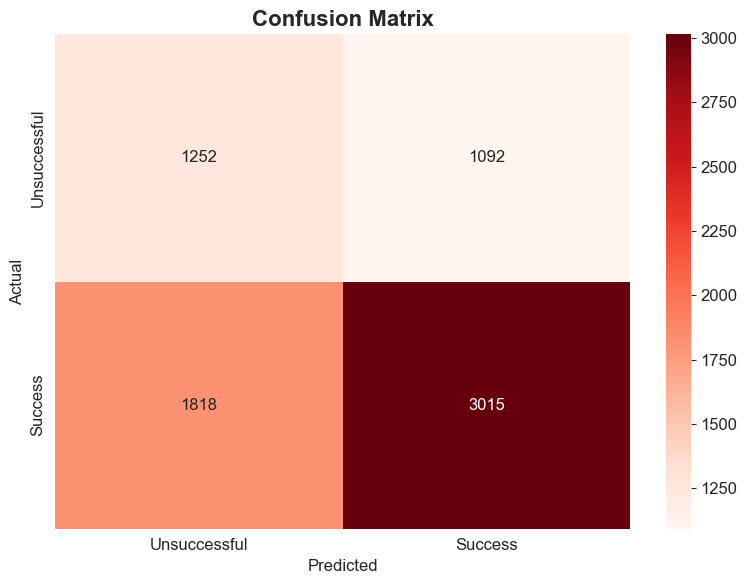

In [9]:
# ── STEP 7: CONFUSION MATRIX ─────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Unsuccessful', 'Success'],
            yticklabels=['Unsuccessful', 'Success'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_9148\1343688363.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', palette='Reds_r')


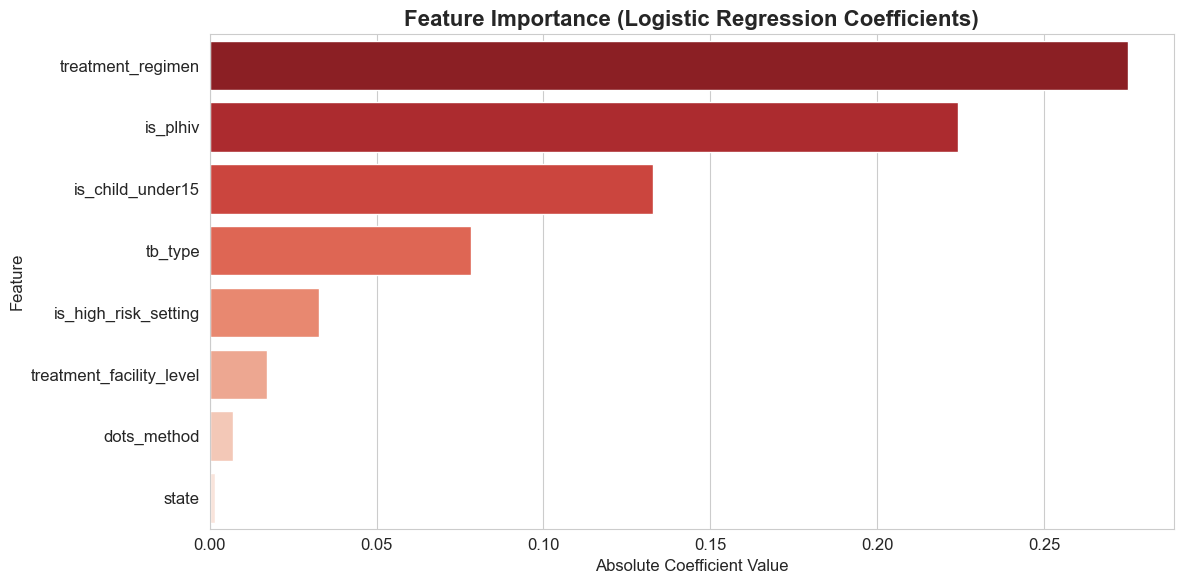

In [10]:
# ── STEP 8: FEATURE IMPORTANCE ───────────────────────────────────

# Get coefficients
importance = pd.DataFrame({
    'feature': features,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=importance, x='importance', y='feature', palette='Reds_r')
plt.title('Feature Importance (Logistic Regression Coefficients)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Prediction Model Summary

A Logistic Regression model was trained to predict TB treatment success using 8 features. 

**Performance:**
- Accuracy: 59.5%
- ROC-AUC: 0.58

**Key findings:**
- Treatment regimen and PLHIV status are the strongest predictors of treatment outcome
- The model initially suffered from class imbalance (67% success rate) — addressed using class_weight='balanced'
- Moderate performance reflects the synthetic nature of the data — real-world models would benefit from additional clinical features such as missed doses, weight progression, and distance from facility

**Public health implication:**
1,092 patients were incorrectly predicted as successful when they actually failed. In a real program this represents a critical gap — these patients would receive no additional support. This highlights that in healthcare, recall matters more than accuracy.